In [1]:
import numpy as np
from matplotlib import pyplot as plt

import h5py

In [2]:
# Load in data results
with h5py.File('data_runs_results.hdf', 'r') as f:
    snr = f['snr'][:]
    valid = snr > 0
    snr = snr[valid]
    snr_A = f['snr_A'][valid]
    snr_E = f['snr_E'][valid]
    time_A = f['time_A'][valid]
    time_E = f['time_E'][valid]
    template_id = f['template_id'][valid]

time = (time_A + time_E) / 2

In [3]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_s = mbhb_sky[0]['CoalescenceTime']

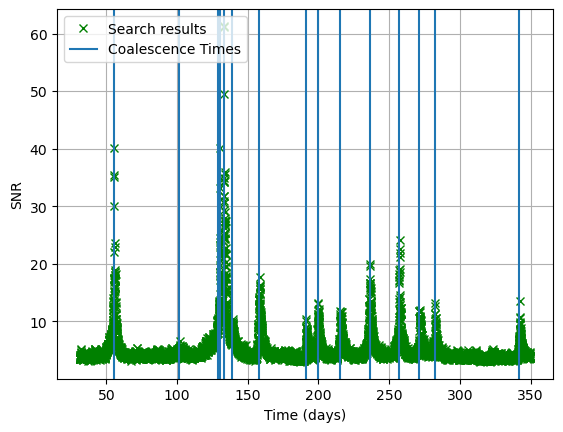

In [4]:
fig, ax = plt.subplots(1)

ax.plot(time / 86400, snr, marker='x', linewidth=0, color='g', label="Search results")
for i, truth_time_s in enumerate(truth_times_s):
    ax.axvline(truth_time_s / 86400)
ax.axvline(np.nan, label="Coalescence Times")

ax.set_xlabel("Time (days)")
ax.set_ylabel("SNR")
ax.legend(loc="upper left")
ax.grid()

In [11]:
def plot_around_time(truth_time_s, time, snr, signal_number=None, time_around=2, truth_times_all=None):
    _, ax = plt.subplots(1)
    valid = np.abs(time - truth_time_s) < (time_around * 86400)
    around_time = time[valid]
    around_snr = snr[valid]

    ax.plot((around_time - truth_time_s) / 86400, around_snr, marker='x', linewidth=0, color='g', label="Search results")
    ax.axvline(0, label='Coalescence Time, {:.3f} days'.format(truth_time_s / 86400))
    if truth_times_all is not None:
        for i, truth_time_other in enumerate(truth_times_all):
            if truth_time_other == truth_time_s:
                continue
            ax.axvline((truth_time_other - truth_time_s) / 86400, color='r', linestyle='--')
    ax.set_xlim(-time_around, time_around)
    print(around_snr.max())
    ax.set_xlabel("Time - truth (days)")
    ax.set_ylabel("SNR")
    ax.grid()
    if signal_number is not None:
        ax.set_title(f"Signal {signal_number}")
    ax.legend(loc='upper left')

40.18278585495118
6.492768634934644
40.06986090601061
40.06986090601061
61.31749311751161
10.477568324868564


17.622259915222926
10.465914050680615
13.18744719404445
11.728317671328718
19.869622275287135
24.130833414208556
12.008579660184411
13.106364194462616
13.571636257038135


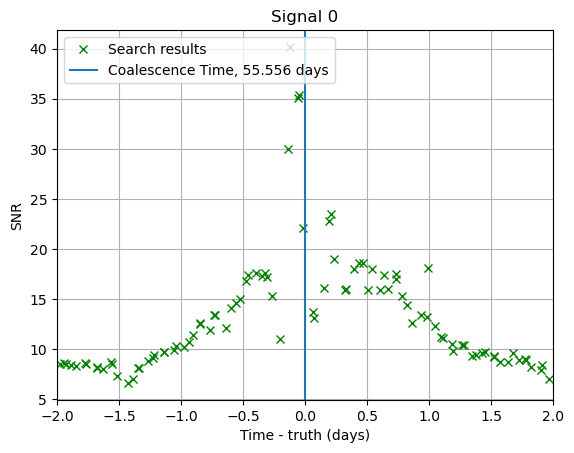

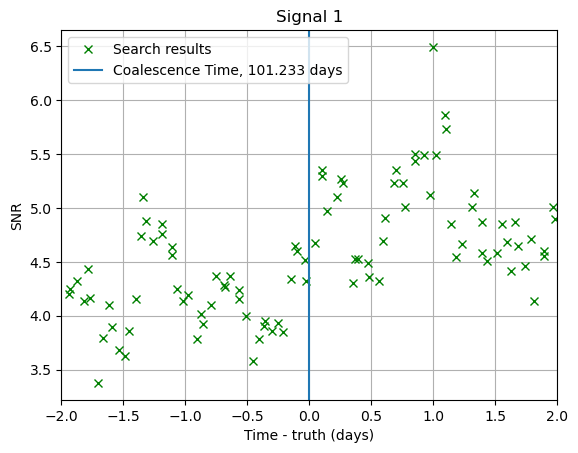

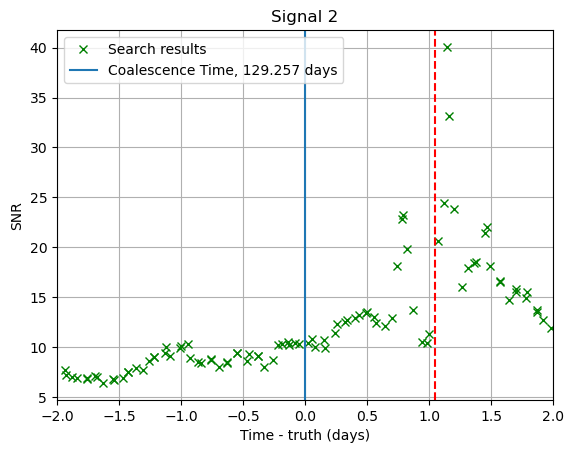

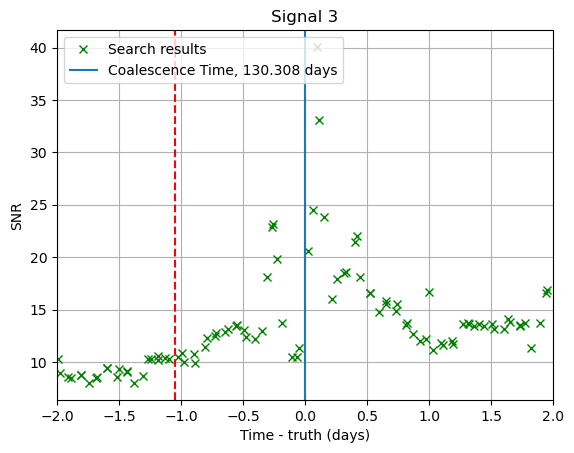

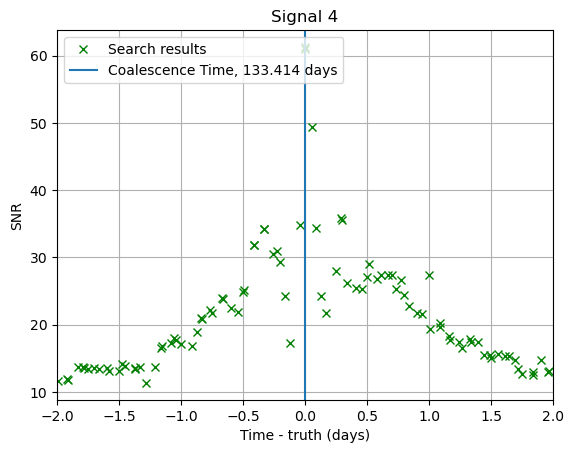

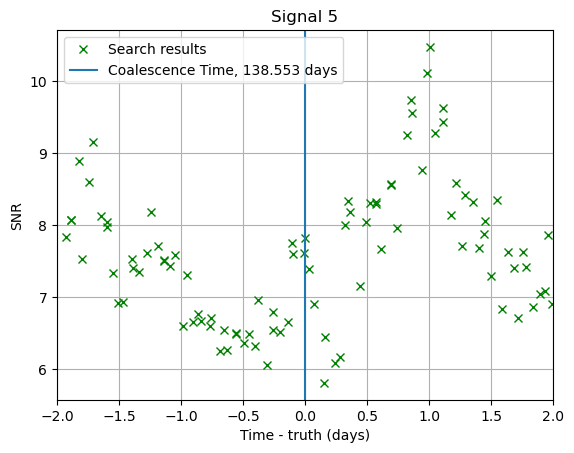

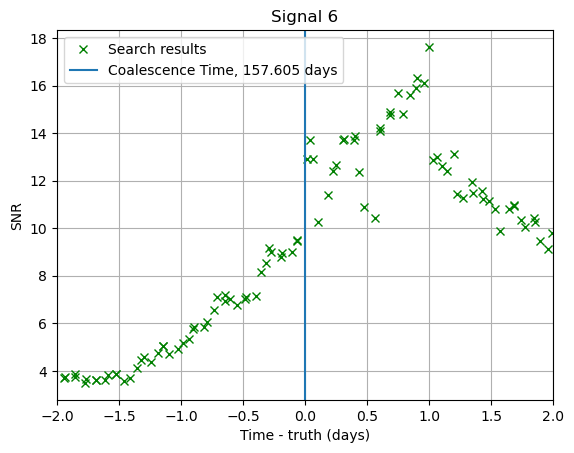

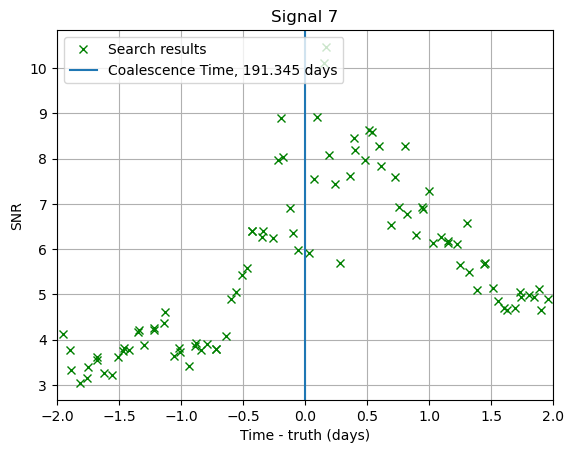

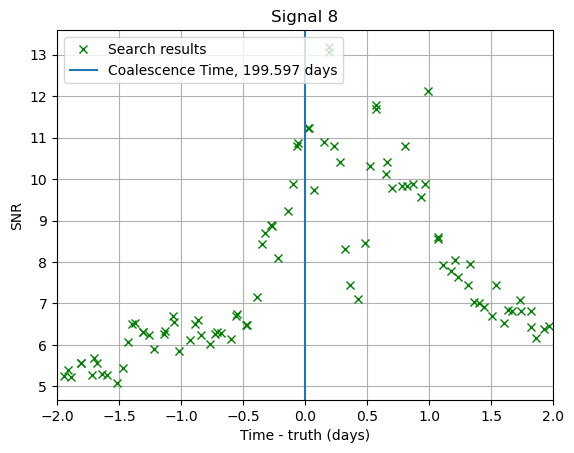

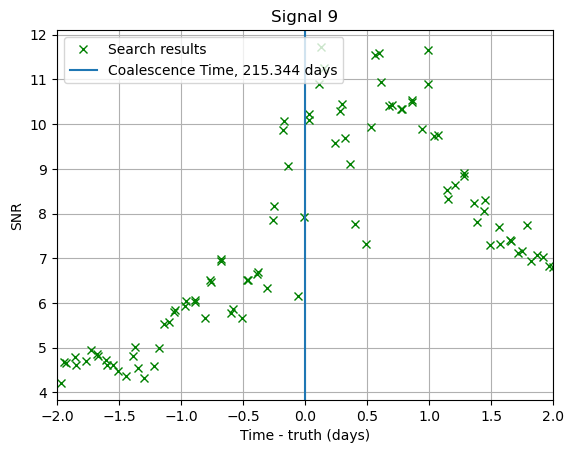

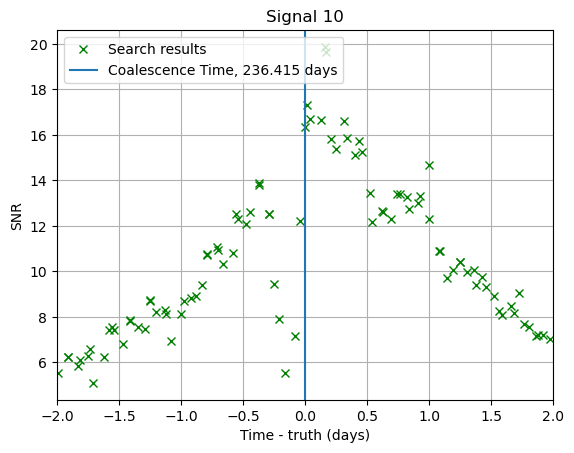

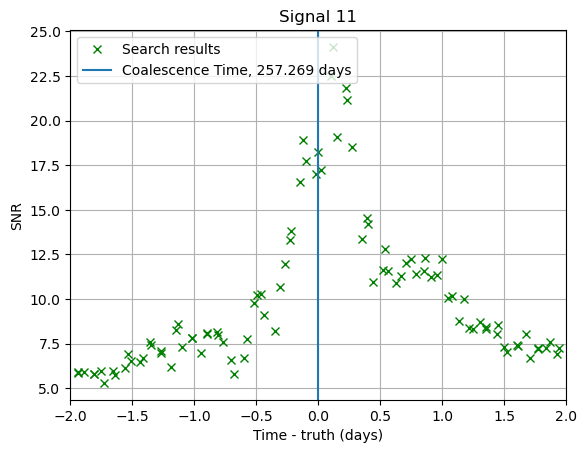

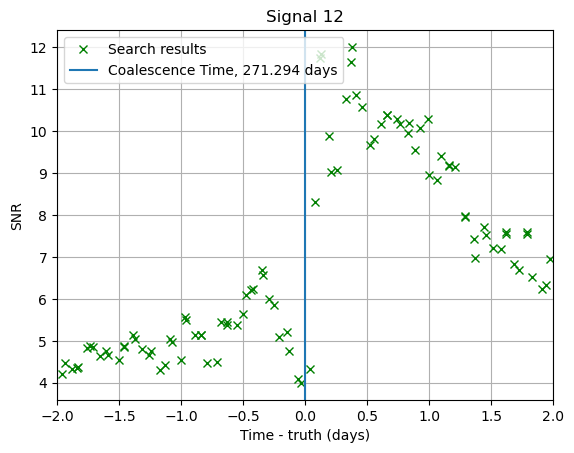

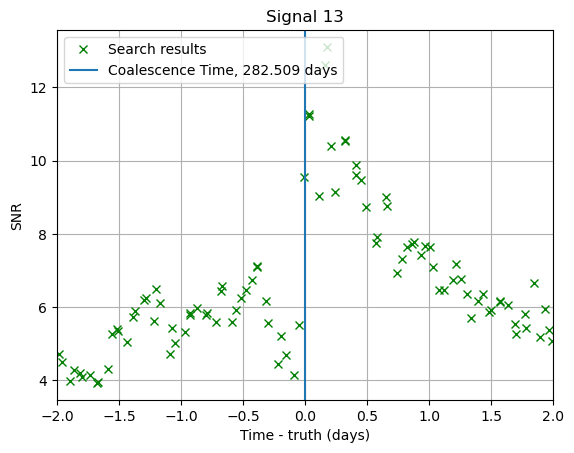

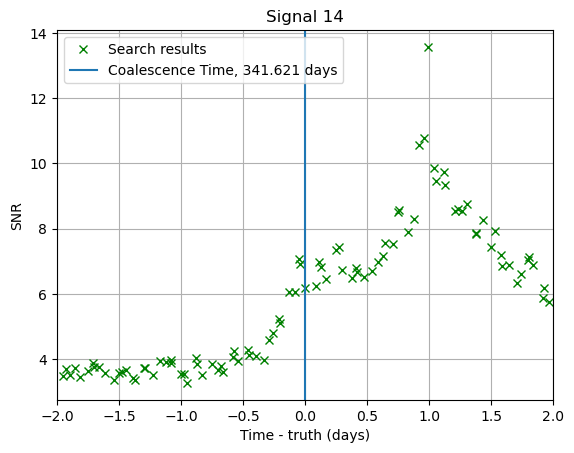

In [15]:
for i, truth_time_s in enumerate(truth_times_s):
    plot_around_time(truth_time_s, time, snr, signal_number=i, truth_times_all=truth_times_s, time_around=2)